In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [17]:
df = pd.read_csv('../data/ml_reviews_ready.csv')

df.columns = df.columns.str.strip()

df = df[['clean_text', 'sentiment']].dropna()
df.rename(columns={'clean_text': 'content'}, inplace=True)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment'])

print(df['label'].unique())  # harus 0,1,2,3

[0 1 2 3]


In [19]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 5000
max_len = 100

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df['content'])

X = tokenizer.texts_to_sequences(df['content'])
X = pad_sequences(X, maxlen=max_len)

y = df['label']

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
import torch

X_train = torch.tensor(X_train).long()
X_test = torch.tensor(X_test).long()
y_train = torch.tensor(y_train.values).long()
y_test = torch.tensor(y_test.values).long()

In [22]:
num_classes = len(y_train.unique())
print(num_classes)  # harus 4

4


In [23]:
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=64, output_dim=4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.embedding(x)
        _, (hidden, _) = self.lstm(x)
        x = self.dropout(hidden[-1])
        return self.fc(x)

model = LSTMModel(max_words, 128, 64, num_classes)

In [24]:
from torch.utils.data import TensorDataset, DataLoader

batch_size = 32

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [25]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

loss_history = []

for epoch in range(10):
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        output = model(X_batch)
        loss = criterion(output, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)

    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

Epoch 1, Loss: 0.7373
Epoch 2, Loss: 0.5676
Epoch 3, Loss: 0.4728
Epoch 4, Loss: 0.3798
Epoch 5, Loss: 0.2845
Epoch 6, Loss: 0.2040
Epoch 7, Loss: 0.1540
Epoch 8, Loss: 0.1098
Epoch 9, Loss: 0.0789
Epoch 10, Loss: 0.0733


In [26]:
from sklearn.metrics import classification_report

model.eval()
with torch.no_grad():
    preds = model(X_test).argmax(dim=1)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95      2678
           1       0.79      0.73      0.76       376
           2       0.89      0.86      0.87       945

    accuracy                           0.92      3999
   macro avg       0.87      0.85      0.86      3999
weighted avg       0.91      0.92      0.91      3999



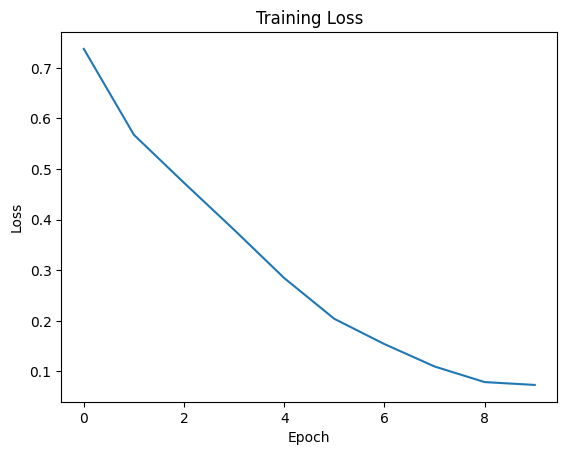

In [27]:
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [28]:
import pickle

torch.save(model.state_dict(), "../app/model.pth")

with open("../app/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open("../app/label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

In [29]:
import json

tokenizer_json = tokenizer.to_json()

with open("../app/tokenizer.json", "w") as f:
    f.write(tokenizer_json)